In [4]:
from langgraph.graph import StateGraph, START, END, add_messages
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated, Literal, List
from pydantic import BaseModel, Field, EmailStr

In [5]:
# state
class SupportAgentState(TypedDict):

  # user info
  user_name: str
  user_email: EmailStr
  user_issue: str

  # issue understanding
  issue_summary: str
  issue_category: str
  affected_system: str
  severity: str
  bussiness_impact: str

  # classify
  decision: str
  confidence: float
  reason: str

  # clarification
  needs_clarification: bool
  clarification_questions: List[str]
  clarification_answer: List[str]
  classification_count: int

  # resolution
  resolution_found: bool
  solution_step: List[str]
  knowledge_source: str
  estimation_resolution_time: str

  # ticket
  ticket_required: bool
  ticket_title: str
  ticket_description: str
  ticket_priority: str
  ticket_category: str
  ticket_id: str
  ticket_status: str

In [7]:
# schemas

# 1. IssueAnalysisSchema
class IssueAnalysisSchema(BaseModel):
    issue_summary: str = Field(
        description="Short summary of the issue"
    )

    issue_category: str = Field(
        description="Category of issue such as Installation, Access, Network, Application, Database"
    )

    affected_system: str = Field(
        description="System or application impacted by the issue"
    )

    severity: Literal[
        "LOW", 
        "MEDIUM", 
        "HIGH", 
        "CRITICAL"
    ]

    bussiness_impact: str = Field(
        description="Impact of the issue on the user's work or business process"
    )

# 2. ClassificationSchema
class ClassificationSchema(BaseModel):

    decision: Literal[
        "USER_SOLVABLE",
        "ADMIN_REQUIRED",
        "NEED_MORE_INFO"
    ]

    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="Confidence score between 0 and 1"
    )

    reason: str = Field(
        description="Reason for selecting the decision"
    )

# 3. ClarificationSchema
class ClarificationSchema(BaseModel):

    needs_clarification: bool

    clarification_questions: List[str] = Field(
        description="List of questions to ask user"
    )

# 4. ResolutionSchema
class ResolutionSchema(BaseModel):

    resolution_found: bool

    solution_step: List[str] = Field(
        description="Simple troubleshooting steps"
    )

    knowledge_source: str = Field(
        description="Knowledge base article or reasoning source"
    )

    estimation_resolution_time: str = Field(
        description="Estimated time required to resolve issue"
    )

# 5. TicketSchema
class TicketSchema(BaseModel):

    ticket_required: bool

    ticket_title: str = Field(
        description="Short ticket title"
    )

    ticket_description: str = Field(
        description="Detailed ticket description"
    )

    ticket_priority: Literal[
        "LOW", 
        "MEDIUM", 
        "HIGH", 
        "CRITICAL"
    ]

    ticket_category: str = Field(
        description="Support category"
    )

# 6. TicketResponseSchema
class TicketResponseSchema(BaseModel):

    ticket_id: str

    ticket_status: str

In [8]:
llm = ChatOllama(model="gemma3:4b")

* Testing Schemas

In [11]:
structured_issue_analysis = llm.with_structured_output(IssueAnalysisSchema)

result = structured_issue_analysis.invoke(
  """
  I am unable to login to VPN.
  It says account locked after multiple attempts.
  """
)

print(f"{result}\n")
print(result.model_dump())

issue_summary="You're encountering an account lock-out issue when trying to log into your VPN after multiple failed login attempts." issue_category='VPN Access' affected_system="VPN Client/Server and potentially the organization's VPN management system" severity='HIGH' bussiness_impact='Loss of access to network resources, potential disruption to work or services.'

{'issue_summary': "You're encountering an account lock-out issue when trying to log into your VPN after multiple failed login attempts.", 'issue_category': 'VPN Access', 'affected_system': "VPN Client/Server and potentially the organization's VPN management system", 'severity': 'HIGH', 'bussiness_impact': 'Loss of access to network resources, potential disruption to work or services.'}


In [12]:
structured_classification_issue = llm.with_structured_output(ClassificationSchema)

result = structured_classification_issue.invoke(
    """
    Issue Summary:
    You're encountering an account lock-out issue when trying to log into your VPN after multiple failed login attempts.

    Category:
    VPN Access

    Determine whether:
    USER_SOLVABLE
    ADMIN_REQUIRED
    NEED_MORE_INFO
    """
)

print(result)

decision='NEED_MORE_INFO' confidence=0.85 reason="While account lockouts are a common VPN issue, the *cause* of the lockout isn't immediately clear. It could be due to: \n\n*   Incorrect password attempts triggering the lockout.\n*   A system-level misconfiguration causing excessive lockouts.\n*   User error (e.g., entering a temporary password incorrectly).\n\nTo determine the best course of action, we need more information such as:\n\n*   Number of failed login attempts.\n*   Time elapsed since the first failed attempt.\n*   Any recent changes to the VPN configuration or user accounts.\n*   The specific VPN client being used."


In [15]:
structured_classification_issue = llm.with_structured_output(ClassificationSchema)

result = structured_classification_issue.invoke(
    """
    Issue Summary:
    Unable to login to VPN due to account lock.

    Category:
    Access Issue

    Determine whether:
    USER_SOLVABLE
    ADMIN_REQUIRED
    NEED_MORE_INFO
    """
)

print(result)

decision='ADMIN_REQUIRED' confidence=0.95 reason='Account lock issues typically require an administrator to unlock the account and reset credentials. This is not a user-specific fix and points to a system configuration problem.'


In [13]:
structured_clarification_issue = llm.with_structured_output(ClarificationSchema)

result = structured_clarification_issue.invoke(
  """
  User Issue:
  I am unable to login to VPN.
  It says account locked after multiple attempts.
  """
)

print(result.model_dump())

{'needs_clarification': True, 'clarification_questions': ['What type of VPN are you trying to access? (e.g., Corporate VPN, Personal VPN like NordVPN or ExpressVPN)', 'Who manages the VPN account for you? (e.g., Your IT department, a third-party provider)', 'Can you provide the exact wording of the error message? (Copy and paste it if possible)', 'When did this issue start occurring?', 'Are you using the correct username and password?', 'Have you tried resetting your password?', 'What device are you attempting to connect with? (e.g., Windows laptop, iPhone, Android phone)']}


In [14]:
result_2 = structured_clarification_issue.invoke(
  """
  User Issue:
  I am unable to login to Corporate VPN.
  It says account locked after multiple attempts.
  """
)

print(result_2.model_dump())

{'needs_clarification': True, 'clarification_questions': ['Can you describe the exact steps you take when trying to log in? (e.g., exactly which website/app are you using?)', "What is the full error message you're seeing *exactly*?", 'Have you recently changed your password?', 'Are you using a personal or company-issued device and account?', 'Can you provide any other details about your VPN usage, such as when this started happening?']}


In [16]:
structured_resolution = llm.with_structured_output(ResolutionSchema)

result = structured_resolution.invoke(
    """
    User wants to install React using Vite.
    Provide simple troubleshooting steps.
    """
)

print(result.model_dump())

{'resolution_found': True, 'solution_step': ['**1. Ensure Node.js and npm are Installed:**', '   - React projects heavily rely on Node.js and npm (Node Package Manager). Make sure you have them installed on your system.', "   - **How to check:** Open a terminal or command prompt and run: `node -v`  and `npm -v`. You should see version numbers if they're installed.", '   - **If not installed:** Download and install Node.js from [https://nodejs.org/](https://nodejs.org/). npm comes bundled with Node.js.', '**2. Create a New Project:**', '   - Start by creating a new React project using Vite.', '   - Open your terminal and navigate to the directory where you want to create your project.', "   - Run this command: `npm create vite@latest my-react-app --template react` (Replace 'my-react-app' with your desired project name.)", '   - This will download Vite and set up a basic React project for you.', '**3. Navigate to the Project Directory:**', '   - Once the project creation is complete, nav

In [17]:
structured_ticket = llm.with_structured_output(TicketSchema)

result = structured_ticket.invoke(
    """
    User VPN account is locked.
    Create ticket details.
    """
)

print(result.model_dump())

{'ticket_required': True, 'ticket_title': 'User VPN Account Locked - Urgent Action Required', 'ticket_description': "A user's VPN account has been locked due to [**Specify Reason Here - CRITICAL! See Options Below**]. This is preventing them from accessing company resources remotely. Immediate action is required to unlock the account and restore access.\n\n**User Information:** \n* **Username:** [**Insert User Username Here**]\n* **Full Name:** [**Insert Full Name Here**]  \n* **Department:** [**Insert Department Here**]", 'ticket_priority': 'HIGH', 'ticket_category': 'IT Support - VPN Access Issues/Security Incident”, //Adjust Category as needed. \u2028”, \u2028”, \u2028” , \u2028” \u2028”, \u2028” \u2028”, \u2028” \u2028”, \u2028”, \u2028” \u2028”, \u2028”, \u2028” \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028” , \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u2028”, \u202

In [24]:
# nodes functions

def analyse_issue(state: SupportAgentState):
  pass

def classify_issue(state: SupportAgentState):
  pass

def ask_clarification(state: SupportAgentState):
  pass

def generate_resolution(state: SupportAgentState):
  pass

def generate_ticket(state: SupportAgentState):
  pass

def final_report(state: SupportAgentState):
  pass

def route_after_classification(state: SupportAgentState):

    if (
        state["decision"] == "NEED_MORE_INFO"
        and state["classification_count"] >= 3
    ):
        return "ADMIN_REQUIRED"

    return state["decision"]

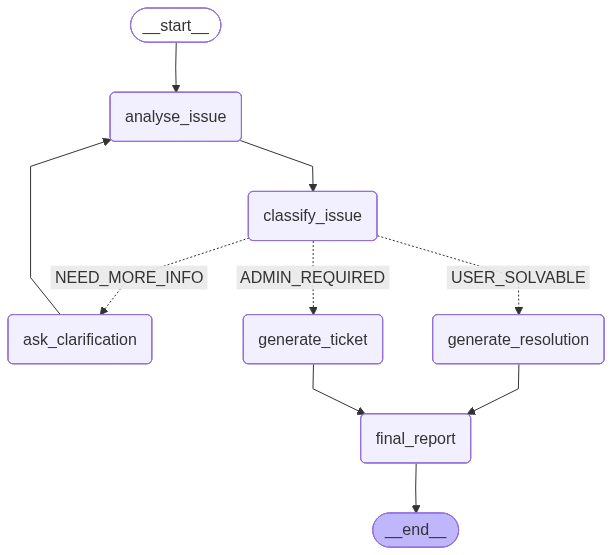

In [25]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(SupportAgentState)

# Nodes
graph.add_node("analyse_issue", analyse_issue)
graph.add_node("classify_issue", classify_issue)
graph.add_node("ask_clarification", ask_clarification)
graph.add_node("generate_resolution", generate_resolution)
graph.add_node("generate_ticket", generate_ticket)
graph.add_node("final_report", final_report)

# Edges
graph.add_edge(START, "analyse_issue")

graph.add_edge(
    "analyse_issue",
    "classify_issue"
)

graph.add_conditional_edges(
    "classify_issue",
    route_after_classification,
    {
        "USER_SOLVABLE": "generate_resolution",
        "ADMIN_REQUIRED": "generate_ticket",
        "NEED_MORE_INFO": "ask_clarification"
    }
)

graph.add_edge(
    "ask_clarification",
    "analyse_issue"
)

graph.add_edge(
    "generate_resolution",
    "final_report"
)

graph.add_edge(
    "generate_ticket",
    "final_report"
)

graph.add_edge(
    "final_report",
    END
)

workflow = graph.compile()

workflow